# Plots for figure.

## Prepare notebook.

### Import Libraries.

In [10]:
import os

import numpy as np
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from tqdm import tqdm
import scvi
import torch


### Define constants and paths.

In [2]:
h5ad_path = "/lustre/groups/ml01/workspace/alessandro.palma/celldreamer/datasets/processed_full_genome/neurips/neurips.h5ad"
dataset_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips"
plots_dir = os.path.join(dataset_dir, "plots_data")
results_dir = os.path.join(dataset_dir, "cfm_runs")

dims = [2, 5, 10, 50, 100, 200]
scvi_models_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs"
dim2scvipath = {
    dim: os.path.join(scvi_models_dir, run) for dim in dims for run in os.listdir(scvi_models_dir) if run.startswith(f"dim-{dim}")
}

dim2yticks = {
    50: [0.0, 2.5, 5.0]
}
dim2xticks = {
    50: [0.0, 2.0, 4.0]
}
dim2xlim = {
    50: [0.0, 4.0]
}
dim2ylim = {
    50: [0.0, 5.0]
}

colors_dict = {
    "dark-red": "#780000",
    "light-red": "#C1121F",
    "light-yellow": "#FDF0D5",
    "dark-blue": "#003049",
    "light-blue": "#669BBC",
}

palette_12 = [
    "#780000",  # dark-red
    "#C1121F",  # light-red
    "#E63946",  # pink
    "#003049",  # dark-blue
    "#669BBC",  # light-blue
    "#A8DADC",  # sky-blue
    "#00798C",  # teal
    "#FDF0D5",  # light-yellow
    "#FFD166",  # gold
    "#EAB543",  # mustard
    "#343A40",  # dark-gray
    "#6C757D",  # neutral-gray
]


### Utility functions.

In [3]:
def plot_llr_densities(
    cllr,
    ullr,
    title="",
    xlabel="",
    ylabel="Density",
    bins="auto",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
):
    # defined ax and figure
    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)
    # corrected
    sns.histplot(cllr, bins=bins, alpha=0.4, color=colors_dict["light-blue"], label="corrected", stat="density", ax=ax)
    sns.kdeplot(cllr, color=colors_dict["dark-blue"], ax=ax)
    # uncorrected
    sns.histplot(ullr, bins=bins, alpha=0.4, color=colors_dict["light-red"], label="uncorrected", stat="density", ax=ax)
    sns.kdeplot(ullr, color=colors_dict["dark-red"], ax=ax)
    ax.grid(False)

    # xticks
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelsize=xticks_size)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.tick_params(axis="y", labelsize=yticks_size)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xlabel(xlabel, size=xlabelsize)
    ax.set_ylabel(ylabel, size=ylabelsize)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels

def plot_llr_boxplot(
    cllr,
    ullr,
    title="",
    xlabel="LLR",
    ylabel="",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
    horizontal=True,   # NEW OPTION
    show_outliers=False,
    linewidth=7,
):
    # Prepare data
    data = pd.DataFrame({
        "Corrected": cllr,
        "Uncorrected": ullr
    })
    data_melted = data.melt(var_name="Condition", value_name="LLR")

    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)

    if horizontal:
        sns.boxplot(
            y="Condition",
            x="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        ax.set_xlabel(xlabel, size=xlabelsize)
        ax.set_ylabel(ylabel, size=ylabelsize)

    else:
        sns.boxplot(
            x="Condition",
            y="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if ylim is not None:
            ax.set_ylim(ylim)
        if xlim is not None:
            ax.set_xlim(xlim)
        ax.set_xlabel(ylabel, size=ylabelsize)
        ax.set_ylabel(xlabel, size=xlabelsize)

    # Ticks
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelsize=xticks_size)

    if yticks is not None:
        ax.set_yticks(yticks)
    ax.tick_params(axis="y", labelsize=yticks_size)

    ax.grid(False)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels


def assign_palette_12(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    n = adata.obs[obs_key].cat.categories.size

    if n > len(palette):
        raise ValueError(f"{obs_key} has {n} categories, but palette has only {len(palette)} colors")

    adata.uns[f"{obs_key}_colors"] = palette[:n]


def assign_cycled_palette(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    cats = adata.obs[obs_key].cat.categories

    colors = [palette[i % len(palette)] for i in range(len(cats))]
    adata.uns[f"{obs_key}_colors"] = colors


def get_ct_and_batch_names(
    adata_full,
    cond_id,
    unique_conds,
    ct_key="cell_type",
    batch_key="batch"
):
    ohe_ct = OneHotEncoder().fit(adata_full.obs[[ct_key]])
    ohe_batch = OneHotEncoder().fit(adata_full.obs[[batch_key]])
    cond_dims = [adata_full.obs[ct_key].nunique(), adata_full.obs[batch_key].nunique()]
    if isinstance(unique_conds, torch.Tensor):
        unique_conds = unique_conds.detach().cpu().numpy()
    ct_vec = ohe_ct.inverse_transform(unique_conds[cond_id][:cond_dims[0]][None])
    batch_vec = ohe_batch.inverse_transform(unique_conds[cond_id][cond_dims[0]:][None])
    return ct_vec[0][0], batch_vec[0][0]




## Read data and results.

### Read adata.

In [4]:
adata = sc.read_h5ad(h5ad_path)
adata = adata[:, adata.var["highly_variable"]]
assign_palette_12(adata, "batch", palette_12)
assign_cycled_palette(adata, "cell_type", palette_12)
adata

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_2357357/1118832288.py:135: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_key] = adata.obs[obs_key].astype("category")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 90261 × 2014
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'dataset_id', 'genome', 'hvg', 'log1p', 'neighbors', 'organism', 'pca', 'umap', 'batch_colors'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

### Plot legend.

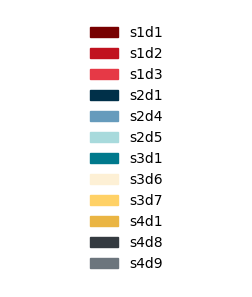

In [5]:
# Get categories and colors
cats = adata.obs["batch"].cat.categories
colors = adata.uns["batch_colors"]

# Create legend handles
handles = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, cats)]

# Make a figure with just the legend
fig_legend = plt.figure(figsize=(3, len(handles)*0.3))
ax = fig_legend.add_subplot(111)
ax.axis("off")
ax.legend(handles=handles, loc="center", frameon=False)

fig_legend.savefig(os.path.join(plots_dir, "batch_leged.svg"), dpi=500)


### Read results for each dimension and combination.

In [6]:
results_dict = {}
runs = os.listdir(results_dir)
for idx, run_id in enumerate(runs):
    print(f"Loading run {run_id} {idx}/{len(runs)}")
    run_res_dict = {}
    run_dir = os.path.join(results_dir, run_id)
    run_res_dir = os.path.join(run_dir, "results")
    for res in tqdm(os.listdir(run_res_dir)):
        res_paths = os.path.join(run_res_dir, res)
        res_array_dic = np.load(res_paths)
        run_res_dict[res] = res_array_dic
    results_dict[run_id] = run_res_dict

Loading run 2026-01-24_00-45-25_89bb3ce8 0/6


100%|██████████| 431/431 [00:12<00:00, 34.46it/s]


Loading run 2026-01-24_00-45-25_da45835b 1/6


100%|██████████| 431/431 [00:10<00:00, 41.03it/s]


Loading run 2026-01-24_00-45-25_ecef9454 2/6


...

100%|██████████| 431/431 [00:11<00:00, 37.89it/s]


Loading run 2026-01-24_00-45-25_6176d031 4/6


100%|██████████| 431/431 [00:11<00:00, 36.03it/s]


Loading run 2026-01-24_00-45-25_21ab6c6f 5/6


100%|██████████| 431/431 [00:10<00:00, 42.26it/s]


### Concatenate results across all combinations for each dimension.

In [7]:
concat_res_dict = {}
for idx, (run, run_dict) in enumerate(results_dict.items()):
    print(f"Loading run {run} {idx}/{len(results_dict)}")
    noise_corrected = []
    llr_corrected = []
    noise_uncorrected = []
    llr_uncorrected = []
    for group_id, group_dict in tqdm(run_dict.items()):
        noise_corrected.append(group_dict["noise_corrected"])
        llr_corrected.append(group_dict["llr_corrected"])
        noise_uncorrected.append(group_dict["noise_uncorrected"])
        llr_uncorrected.append(group_dict["llr_uncorrected"])
    print(f"Concatenating results...")
    noise_corrected = np.concatenate(noise_corrected, axis=0)    
    llr_corrected = np.concatenate(llr_corrected, axis=0)    
    noise_uncorrected = np.concatenate(noise_uncorrected, axis=0)    
    llr_uncorrected = np.concatenate(llr_uncorrected, axis=0)  
    print(f"{noise_corrected.shape=}")
    print(f"{llr_corrected.shape=}")
    print(f"{noise_uncorrected.shape=}")
    print(f"{llr_uncorrected.shape=}")
    dim = noise_corrected.shape[-1]
    concat_res_dict[(run, dim)] = {
        "noise_corrected": noise_corrected,
        "llr_corrected": llr_corrected,
        "noise_uncorrected": noise_uncorrected,
        "llr_uncorrected": llr_uncorrected,
    }


Loading run 2026-01-24_00-45-25_89bb3ce8 0/6


100%|██████████| 431/431 [00:00<00:00, 1720.97it/s]


Concatenating results...
noise_corrected.shape=(90261, 10)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 10)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_da45835b 1/6


100%|██████████| 431/431 [00:00<00:00, 1836.78it/s]


Concatenating results...
noise_corrected.shape=(90261, 5)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 5)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_ecef9454 2/6


...

Concatenating results...
noise_corrected.shape=(90261, 2)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 2)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_6176d031 4/6


100%|██████████| 431/431 [00:00<00:00, 1205.72it/s]


Concatenating results...
noise_corrected.shape=(90261, 100)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 100)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_21ab6c6f 5/6


100%|██████████| 431/431 [00:00<00:00, 1538.82it/s]

Concatenating results...
noise_corrected.shape=(90261, 50)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 50)
llr_uncorrected.shape=(90261,)


### Match the estimated likelihood back to the observations.

In [31]:
from collections import defaultdict
# retrieve unique train conditions
C_train = np.concatenate(
    (
        OneHotEncoder().fit_transform(adata.obs[["cell_type"]]).toarray(),
        OneHotEncoder().fit_transform(adata.obs[["batch"]]).toarray(),
    ), axis=1
)
unique_conds = np.unique(C_train, axis=0)

df_list = []

# iterating over unique conditions
for idx in tqdm(range(unique_conds.shape[0])):
    # retrieve cell type and batch names
    cell_type, batch = get_ct_and_batch_names(
        adata,
        idx,
        unique_conds,
        ct_key="cell_type",
        batch_key="batch"
    )
    cond_mask =  (adata.obs["cell_type"] == cell_type) & (adata.obs["batch"] == batch)
    cond_index = adata.obs.index[cond_mask]

    cond_key = f"CT:{cell_type.replace('/', '-')}-B:{batch.replace('/', '-')}.npz"
    cond_cllr_dict = {run: cond_dict[cond_key]["llr_corrected"] for run, cond_dict in results_dict.items()}
    cond_ullr_dict = {run: cond_dict[cond_key]["llr_uncorrected"] for run, cond_dict in results_dict.items()}
    run2dim_dict = {run: cond_dict[cond_key]["noise_corrected"].shape[-1] for run, cond_dict in results_dict.items()}
    cond_rows = defaultdict(list)
    for run, cllr in cond_cllr_dict.items():
        dim = run2dim_dict[run]
        ullr = cond_ullr_dict[run]
        assert ullr.shape[0] == cllr.shape[0]
        assert ullr.shape[0] == len(cond_index)
        run_dict = {
            f"llr:corrected:{dim}": cllr,
            f"llr:uncorrected:{dim}": ullr
        }
        for k, v in run_dict.items():
            cond_rows[k] = v
    cond_df = pd.DataFrame(cond_rows, index=cond_index)
    df_list.append(cond_df)

llr_df = pd.concat(df_list, axis=0)
llr_df.index.name = "index"
adata.obs.index.name = "index"
print(f"{llr_df.shape=}")
assert llr_df.shape[0] == adata.shape[0]
llr_df.head()

100%|██████████| 431/431 [00:03<00:00, 142.26it/s]

llr_df.shape=(90261, 12)


,llr:corrected:10,llr:uncorrected:10,llr:corrected:5,llr:uncorrected:5,llr:corrected:200,llr:uncorrected:200,llr:corrected:2,llr:uncorrected:2,llr:corrected:100,llr:uncorrected:100,llr:corrected:50,llr:uncorrected:50
index,,,,,,,,,,,,
CACGGGTGTCCTGGGT-1-s4d9,0.074929,-0.689447,-1.223350,-1.477645,-0.064638,-0.146505,-1.549888,0.936686,-0.062651,-0.212156,-0.105824,-0.087765
CATACCCAGCATTGTC-1-s4d9,-0.021253,-0.493986,-0.528515,-1.029683,-0.014393,-0.996554,-0.486938,1.860219,-0.150418,-1.013270,-0.015992,-1.199293
GTAATGCTCGCTGACG-1-s4d9,-0.896514,-0.325539,-0.985894,-0.948556,-0.124901,0.301290,-1.160391,0.153335,-0.068951,-0.062361,-0.189932,-0.485718
TTGTGTTAGTATTCCG-1-s4d9,-0.466321,-0.925330,-0.053193,-1.162387,-0.119559,-0.508748,-1.022970,0.340523,0.054129,-0.350990,-0.007812,-1.224478
GCCTGTTTCCGCTGTT-1-s4d9,0.067018,-0.785262,-0.758076,-1.460188,-0.038671,-0.794925,-1.542395,1.114736,0.017706,-0.553778,-0.254666,-0.426475


### Merge with adata obs.

In [ ]:
is_llr_data_joined = False
if not is_llr_data_joined:
    obs_df = adata.obs
    obs_df_joined = obs_df.join(llr_df, on="index", how="inner")
    assert obs_df_joined.shape[0] == adata.shape[0]
    assert obs_df_joined.shape[1] == adata.obs.shape[1] + llr_df.shape[1]
    adata.obs = obs_df_joined
    is_llr_data_joined = True
adata.obs.head()

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,llr:corrected:5,llr:uncorrected:5,llr:corrected:200,llr:uncorrected:200,llr:corrected:2,llr:uncorrected:2,llr:corrected:100,llr:uncorrected:100,llr:corrected:50,llr:uncorrected:50
index,,,,,,,,,,,,,,,,,,,,,
GCATTAGCATAAGCGG-1-s1d1,893,6.723979,0.356535,G1,115,2828.0,5.0,Naive CD20+ B IGKC+,s1d1,NaN,...,-2.525116,4.735158,-0.112811,2.433709,0.145662,0.898302,-0.041830,2.084675,-0.302896,5.316449
TACAGGTGTTAGAGTA-1-s1d1,2606,8.008829,1.292643,S,137,8819.0,21.0,CD14+ Mono,s1d1,NaN,...,-0.656467,-0.965270,-0.057334,-0.687189,0.692025,-0.619067,-0.123832,-1.300705,0.093122,1.174895
AGGATCTAGGTCTACT-1-s1d1,1867,6.959707,0.970558,G2M,116,4088.0,12.0,Naive CD20+ B IGKC+,s1d1,NaN,...,-0.131707,1.733604,0.055848,0.626549,0.852164,0.718332,-0.114581,0.133095,-0.124112,-0.013093
GTAGAAAGTGACACAG-1-s1d1,2360,6.109234,1.232604,G2M,124,4447.0,9.0,HSC,s1d1,NaN,...,-2.493719,-0.187970,-0.094612,-0.361757,2.561245,2.613558,-0.071246,-0.224796,0.112968,5.458227
TCCGAAAAGGATCATA-1-s1d1,455,0.294394,0.044585,S,132,12875.0,24.0,Reticulocyte,s1d1,0.735261,...,0.300859,0.374532,0.079870,1.371888,0.561615,0.638196,-0.019420,2.211741,0.080247,1.854025


## Plot results of log density ratio computation.

### Plot histogram of mean absolute log ratio.

In [33]:
dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_densities(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        xticks=xticks,
        yticks=yticks,
        xlim=xlim,
        ylim=ylim,
    )
    dim2fig_abs[(run, dim)] = fig

    fig_legend = plt.figure(figsize=(2, 2))
    ax = fig_legend.add_subplot(111)  # Add a dummy axes
    ax.axis("off")

    fig_legend.legend(
        handles,
        labels,
        loc="center",
        fontsize=50,
        ncol=30,
        frameon=False
    )
    fig_legend.tight_layout()
    legend_path = os.path.join(run_plots_dir, "legend.svg")
    fig_legend.savefig(legend_path, dpi=300, bbox_inches="tight")
    plt.close(fig_legend)

    image_path = os.path.join(run_plots_dir, "llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


100%|██████████| 6/6 [00:10<00:00,  1.82s/it]


### Boxplot of mean absolute log density ratio.

In [34]:
box_dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_boxplot(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        horizontal=True,
        show_outliers=False,
        linewidth=10,
        xticks_size=30,
        yticks_size=30,
        xlabelsize=30,
        ylabelsize=40,
    )
    box_dim2fig_abs[(run, dim)] = fig

    # break
    image_path = os.path.join(run_plots_dir, "no_outliers_horizontal_boxplot_llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


  0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_2357357/1118832288.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 17%|█▋        | 1/6 [00:00<00:02,  1.76it/s]/tmp/ipykernel_2357357/1118832288.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 33%|███▎      | 2/6 [00:01<00:02,  1.66it/s]/tmp/ipykernel_2357357/1118832288.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 50%|█████     | 3/6 [00:01<00:01,  1.65it/s]/tmp/ipykernel_2357357/1118832288.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

## Plot corrected.

### Color by categorical variables.

In [35]:
compute_stuff = True
s = 15
uncorr_dim2umap_batch = {}
uncorr_dim2umap_cell_type = {}
for d in tqdm(dims):
    batch_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_cell_type_size{s}.png")
    if compute_stuff:
        sc.pp.pca(adata, n_comps=d, key_added=f"X_pca_{d}")
        sc.pp.neighbors(adata, use_rep=f"X_pca_{d}", key_added=f"neighbors_pca_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_pca_{d}", key_added=f"umap_pca_{d}",)
    fig_batch = sc.pl.embedding(adata, f"umap_pca_{d}", s=s, color="batch", frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_pca_{d}", s=s, color="cell_type", frameon=False, legend_loc=None, return_fig=True)
    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    uncorr_dim2umap_batch[d] = fig_batch
    uncorr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

100%|██████████| 6/6 [07:44<00:00, 77.45s/it] 


### Color by estimated ratio.

In [36]:
compute_stuff = True
save_results = True

s = 15

uncorr_dim2umap_ullr = {}
uncorr_dim2umap_cllr = {}

vmin = -5
vmax = 5.0

for d in tqdm(dims):

    ullr_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_uncorr_llr_size{s}.png")
    cllr_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_corr_llr_size{s}.png")

    fig_uncorrected_llr = sc.pl.embedding(adata, f"umap_pca_{d}", color=f"llr:uncorrected:{d}", s=s, frameon=False, legend_loc=None, return_fig=True, 
        cmap="magma", vmin=vmin, vmax=vmax)
    fig_corrected_llr = sc.pl.embedding(adata, f"umap_pca_{d}", color=f"llr:corrected:{d}", s=s, 
                                        cmap="magma", frameon=False, legend_loc=None, return_fig=True,
    vmin=vmin, vmax=vmax)

    uncorr_dim2umap_ullr[d] = fig_uncorrected_llr
    uncorr_dim2umap_cllr[d] = fig_corrected_llr

    fig_uncorrected_llr.savefig(ullr_dim_file, dpi=500)
    fig_corrected_llr.savefig(cllr_dim_file, dpi=500)
    plt.close(fig_uncorrected_llr)
    plt.close(fig_corrected_llr)

100%|██████████| 6/6 [00:12<00:00,  2.02s/it]


## Plot correted cell states.

### Color by categorical covariates.

In [37]:
compute_stuff = True
s = 15
corr_dim2umap_batch = {}
corr_dim2umap_cell_type = {}
adata = adata[:, adata.var["highly_variable"]]
for d in tqdm(dims):
    if compute_stuff:
        scvi_model_dir = dim2scvipath[d]
        scvi_model = scvi.model.SCVI.load(scvi_model_dir, adata=adata.copy())
        adata.obsm[f"X_scvi_{d}"] = scvi_model.get_latent_representation()

        sc.pp.neighbors(adata, use_rep=f"X_scvi_{d}", key_added=f"neighbors_scvi_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_scvi_{d}", key_added=f"umap_scvi_{d}", min_dist=0.3)

    batch_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_cell_type_size{s}.png")

    fig_batch = sc.pl.embedding(adata, f"umap_scvi_{d}", color="batch", s=s, frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_scvi_{d}", color="cell_type", s=s, frameon=False, legend_loc=None, return_fig=True)

    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    corr_dim2umap_batch[d] = fig_batch
    corr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

  0%|          | 0/6 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs/dim-200-2026-01-24_00-25-4
         1_a1506ada/model.pt already downloaded                                                                    


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...


/tmp/ipykernel_2357357/1298988313.py:10: ImplicitModificationWarning: Setting element `.obsm['X_scvi_2']` of view, initializing view as actual.
  adata.obsm[f"X_scvi_{d}"] = scvi_model.get_latent_representation()
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
 17%|█▋        | 1/6 [01:06<05:34, 66.97s/it]

INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs/dim-50-2026-01-24_00-25-41
         _e85f7e0d/model.pt already downloaded                                                                     


...

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
 67%|██████▋   | 4/6 [03:54<01:51, 55.64s/it]

INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs/dim-100-2026-01-24_00-25-4
         1_4c051b4f/model.pt already downloaded                                                                    


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
 83%|████████▎ | 5/6 [04:46<00:54, 54.35s/it]

INFO     File                                                                                                      
         /home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs/dim-200-2026-01-24_00-25-4
         1_a1506ada/model.pt already downloaded                                                                    


/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
100%|██████████| 6/6 [05:40<00:00, 56.76s/it]


### Color by estimated llr.

In [39]:
compute_stuff = False
save_results = True
s = 15

vmin = -5
vmax = 5.0


uncorr_dim2umap_ullr = {}
uncorr_dim2umap_cllr = {}

for d in tqdm(dims):

    ullr_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_uncorr_llr_size{s}.png")
    cllr_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_corr_llr_size{s}.png")

    fig_uncorrected_llr = sc.pl.embedding(adata, f"umap_scvi_{d}", color=f"llr:uncorrected:{d}", s=s, frameon=False, legend_loc=None, return_fig=True,
                                          cmap="magma", vmin=vmin, vmax=vmax)
    fig_corrected_llr = sc.pl.embedding(adata, f"umap_scvi_{d}", color=f"llr:corrected:{d}", s=s, frameon=False, legend_loc=None, return_fig=True,
                                          cmap="magma", vmin=vmin, vmax=vmax)

    uncorr_dim2umap_ullr[d] = fig_uncorrected_llr
    uncorr_dim2umap_cllr[d] = fig_corrected_llr

    fig_uncorrected_llr.savefig(ullr_dim_file, dpi=500)
    fig_corrected_llr.savefig(cllr_dim_file, dpi=500)
    plt.close(fig_uncorrected_llr)
    plt.close(fig_corrected_llr)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:12<00:00,  2.06s/it]
